In [22]:
import pandas as pd
import pingouin as pg
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import statsmodels.api as sm

In [ ]:
#Load csv file into dataframe
df = pd.read_csv('../../../RadiomiK/Features_Global/cyl0_glob.csv')
df

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition
0,32338.0,32455.0,2.274190e+12,2.895033,67.0,2.497114,32543.0,37.152096,32395.408399,32396.0,...,5.281891,0.006676,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1
1,32339.0,32452.0,2.274172e+12,2.877628,64.0,2.738984,32537.0,35.899859,32395.286571,32396.0,...,7.479260,0.003848,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2
2,32336.0,32451.0,2.274120e+12,2.888346,65.5,2.623098,32539.0,36.830678,32394.909552,32395.0,...,5.642828,0.006768,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3
3,32329.0,32458.0,2.273763e+12,3.011258,72.0,2.507076,32539.0,40.127979,32392.365482,32391.0,...,7.878124,0.004552,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1
4,32330.0,32455.0,2.273936e+12,2.977948,69.0,2.523126,32533.0,39.099131,32393.598985,32394.0,...,5.701022,0.007985,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3
5,32332.0,32457.0,2.274011e+12,2.992587,69.0,2.583730,32540.0,39.163642,32394.129211,32395.0,...,6.173102,0.007797,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2
6,32326.0,32460.0,2.274073e+12,3.092705,76.0,2.553842,32553.0,42.526532,32394.570835,32394.0,...,10.138136,0.006199,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3
7,32329.0,32461.0,2.274126e+12,3.078267,75.0,2.653363,32555.0,42.117601,32394.946931,32394.0,...,9.988204,0.005321,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2
8,32329.0,32462.0,2.274146e+12,3.073643,77.0,2.461091,32551.0,42.435558,32395.088140,32396.0,...,7.192142,0.010203,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1
9,32317.0,32470.0,2.274039e+12,3.265483,88.0,2.505607,32577.0,48.602242,32394.315644,32396.0,...,11.482843,0.009766,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2


In [24]:
#Scale the data
scaler = MinMaxScaler()
df_reduced= df.iloc[:, :86]
df_last = df.iloc[:, 86:]
df_scaled = pd.DataFrame(scaler.fit_transform(df_reduced.iloc[:, :86]), columns=df_reduced.columns)
df_joined = df_scaled.join(df_last)
df = df_joined
df_joined

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition
0,0.068021,0.003617,0.761621,0.413320,0.321429,0.257660,0.007628,0.278147,0.003305,0.004840,...,0.038008,0.446275,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1
1,0.068905,0.000904,0.761606,0.405023,0.294643,0.520443,0.003051,0.259122,0.003187,0.004840,...,0.057422,0.169180,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2
2,0.066254,0.000000,0.761559,0.410132,0.308036,0.394536,0.004577,0.273264,0.002822,0.003872,...,0.041197,0.455349,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3
3,0.060071,0.006329,0.761244,0.468721,0.366071,0.268483,0.004577,0.323360,0.000359,0.000000,...,0.060946,0.238157,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1
4,0.060954,0.003617,0.761397,0.452843,0.339286,0.285920,0.000000,0.307729,0.001553,0.002904,...,0.041711,0.574620,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3
5,0.062721,0.005425,0.761463,0.459821,0.339286,0.351765,0.005339,0.308709,0.002066,0.003872,...,0.045882,0.556134,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2
6,0.057420,0.008137,0.761518,0.507545,0.401786,0.319292,0.015256,0.359802,0.002494,0.002904,...,0.080914,0.399529,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3
7,0.060071,0.009042,0.761565,0.500663,0.392857,0.427418,0.016781,0.353589,0.002858,0.002904,...,0.079589,0.313493,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2
8,0.060071,0.009946,0.761583,0.498459,0.410714,0.218521,0.013730,0.358420,0.002995,0.004840,...,0.054885,0.791936,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1
9,0.049470,0.017179,0.761488,0.589904,0.508929,0.266886,0.033562,0.452112,0.002247,0.004840,...,0.092794,0.749127,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2


In [25]:
#AGGIUNGO LA COLONNA PROTOCOLLO
# Define conditions and corresponding values for the new column
conditions = [
    (df['Dose'] == 2) & (df['ASIR'] == 'FBP') & (df['Manufacturer'] == 'GE MEDICAL SYSTEMS'), (df['Dose'] == 2) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 2) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 2) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 4) & (df['ASIR'] == 'FBP'), (df['Dose'] == 4) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 4) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 4) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 7) & (df['ASIR'] == 'FBP'), (df['Dose'] == 7) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 7) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 7) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 14) & (df['ASIR'] == 'FBP'), (df['Dose'] == 14) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 14) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 14) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 2) & (df['ASIR'] == 'FBP') & (df['Manufacturer'] == 'TOSHIBA'), (df['Dose'] == 2) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 2) & (df['ASIR'] == 'STD'), (df['Dose'] == 2) & (df['ASIR'] == 'STRONG'),
    (df['Dose'] == 4) & (df['ASIR'] == 'FBP'), (df['Dose'] == 4) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 4) & (df['ASIR'] == 'STD'), (df['Dose'] == 4) & (df['ASIR'] == 'STRONG'),
    (df['Dose'] == 8) & (df['ASIR'] == 'FBP'), (df['Dose'] == 8) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 8) & (df['ASIR'] == 'STD'), (df['Dose'] == 8) & (df['ASIR'] == 'STRONG'),
    (df['Dose'] == 16) & (df['ASIR'] == 'FBP'), (df['Dose'] == 16) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 16) & (df['ASIR'] == 'STD'), (df['Dose'] == 16) & (df['ASIR'] == 'STRONG'),
    ]

new_column_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
                     27, 28, 29, 30, 31, 32]

# Add a new column based on the conditions
df['PROTOCOL'] = np.select(conditions, new_column_values, default=None)

# Print the updated DataFrame
df

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_gldm_SmallDependenceLowGrayLevelEmphasis,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL
0,0.068021,0.003617,0.761621,0.413320,0.321429,0.257660,0.007628,0.278147,0.003305,0.004840,...,0.446275,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1,24
1,0.068905,0.000904,0.761606,0.405023,0.294643,0.520443,0.003051,0.259122,0.003187,0.004840,...,0.169180,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2,24
2,0.066254,0.000000,0.761559,0.410132,0.308036,0.394536,0.004577,0.273264,0.002822,0.003872,...,0.455349,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3,24
3,0.060071,0.006329,0.761244,0.468721,0.366071,0.268483,0.004577,0.323360,0.000359,0.000000,...,0.238157,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1,20
4,0.060954,0.003617,0.761397,0.452843,0.339286,0.285920,0.000000,0.307729,0.001553,0.002904,...,0.574620,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3,20
5,0.062721,0.005425,0.761463,0.459821,0.339286,0.351765,0.005339,0.308709,0.002066,0.003872,...,0.556134,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2,20
6,0.057420,0.008137,0.761518,0.507545,0.401786,0.319292,0.015256,0.359802,0.002494,0.002904,...,0.399529,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3,23
7,0.060071,0.009042,0.761565,0.500663,0.392857,0.427418,0.016781,0.353589,0.002858,0.002904,...,0.313493,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2,23
8,0.060071,0.009946,0.761583,0.498459,0.410714,0.218521,0.013730,0.358420,0.002995,0.004840,...,0.791936,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1,23
9,0.049470,0.017179,0.761488,0.589904,0.508929,0.266886,0.033562,0.452112,0.002247,0.004840,...,0.749127,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2,19


In [26]:
# Add the column PROTOCOL_new to the dataframe 
#this column contains only the protocols of the features extraction ordered by dose and asir level, first for GE and then for Toshiba

conditions = [
    (df['Dose'] == 4) & (df['ASIR'] == 'ASIR70') & (df['Manufacturer'] == 'GE MEDICAL SYSTEMS'),
    (df['Dose'] == 7) & (df['ASIR'] == 'FBP'), (df['Dose'] == 7) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 7) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 7) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 14) & (df['ASIR'] == 'FBP'), (df['Dose'] == 14) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 2) & (df['ASIR'] == 'MILD') & (df['Manufacturer'] == 'TOSHIBA'),
    (df['Dose'] == 2) & (df['ASIR'] == 'STD'), (df['Dose'] == 2) & (df['ASIR'] == 'STRONG'),
    (df['Dose'] == 4) & (df['ASIR'] == 'FBP'), (df['Dose'] == 4) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 4) & (df['ASIR'] == 'STD'), (df['Dose'] == 4) & (df['ASIR'] == 'STRONG'),
    ]

new_column_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

# Add a new column based on the conditions
df['PROTOCOL_new'] = np.select(conditions, new_column_values, default=None)

# Print the updated DataFrame
df

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL,PROTOCOL_new
0,0.068021,0.003617,0.761621,0.413320,0.321429,0.257660,0.007628,0.278147,0.003305,0.004840,...,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1,24,14
1,0.068905,0.000904,0.761606,0.405023,0.294643,0.520443,0.003051,0.259122,0.003187,0.004840,...,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2,24,14
2,0.066254,0.000000,0.761559,0.410132,0.308036,0.394536,0.004577,0.273264,0.002822,0.003872,...,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3,24,14
3,0.060071,0.006329,0.761244,0.468721,0.366071,0.268483,0.004577,0.323360,0.000359,0.000000,...,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1,20,10
4,0.060954,0.003617,0.761397,0.452843,0.339286,0.285920,0.000000,0.307729,0.001553,0.002904,...,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3,20,10
5,0.062721,0.005425,0.761463,0.459821,0.339286,0.351765,0.005339,0.308709,0.002066,0.003872,...,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2,20,10
6,0.057420,0.008137,0.761518,0.507545,0.401786,0.319292,0.015256,0.359802,0.002494,0.002904,...,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3,23,13
7,0.060071,0.009042,0.761565,0.500663,0.392857,0.427418,0.016781,0.353589,0.002858,0.002904,...,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2,23,13
8,0.060071,0.009946,0.761583,0.498459,0.410714,0.218521,0.013730,0.358420,0.002995,0.004840,...,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1,23,13
9,0.049470,0.017179,0.761488,0.589904,0.508929,0.266886,0.033562,0.452112,0.002247,0.004840,...,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2,19,9


In [27]:
column_names = df.columns.tolist()
df_sorted = df.sort_values(['PROTOCOL_new', column_names[0]])

df_sorted

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL,PROTOCOL_new
34,0.897527,0.992767,0.998695,1.000000,0.991071,0.676811,0.932113,1.000000,0.990456,0.992256,...,RAD_GE_LUNG_7_FBP_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,FBP,1,9,2
35,0.909011,0.985895,0.998835,0.941912,0.892857,0.825179,0.924485,0.888536,0.991484,0.992256,...,RAD_GE_LUNG_7_FBP_3,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,FBP,3,9,2
36,0.909011,1.000000,0.999566,0.991802,1.000000,0.820691,1.000000,0.986642,0.996725,0.998064,...,RAD_GE_LUNG_7_FBP_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,FBP,2,9,2
25,0.907244,0.982821,0.998674,0.945802,0.901786,0.685144,0.912281,0.904111,0.990329,0.992256,...,RAD_GE_LUNG_7_ASIR10_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR10,1,10,3
24,0.916961,0.978300,0.998818,0.892967,0.803571,0.821103,0.905416,0.806636,0.991387,0.992256,...,RAD_GE_LUNG_7_ASIR10_3,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR10,3,10,3
23,0.917845,0.990416,0.999544,0.940503,0.910714,0.807972,0.975591,0.897646,0.996588,0.998064,...,RAD_GE_LUNG_7_ASIR10_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR10,2,10,3
26,0.995583,0.903255,0.999164,0.025649,0.008929,1.000000,0.742944,0.009020,0.993986,0.994192,...,RAD_GE_LUNG_7_ASIR40_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR40,1,11,4
28,0.998233,0.905063,0.999393,0.000000,0.000000,0.712950,0.739130,0.000000,0.995633,0.996128,...,RAD_GE_LUNG_7_ASIR40_3,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR40,3,11,4
27,1.000000,0.910488,1.000000,0.048556,0.044643,0.627371,0.746758,0.023894,1.000000,1.000000,...,RAD_GE_LUNG_7_ASIR40_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR40,2,11,4
29,0.948763,0.938517,0.998492,0.618382,0.455357,0.766019,0.816171,0.446501,0.989102,0.989351,...,RAD_GE_LUNG_7_ASIR70_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR70,1,12,5


In [28]:
grouped_data = df_sorted.groupby('PROTOCOL_new')[column_names[0]].agg(['mean', 'std'])

grouped_data

,mean,std
PROTOCOL_new,,
2,0.905183,0.006630
3,0.914016,0.005882
4,0.997939,0.002223
5,0.953475,0.004175
6,0.932420,0.000625
7,0.957597,0.001249
8,0.033274,0.000510
9,0.049470,0.000883
10,0.061249,0.001349


In [29]:
#Load the csv file that contains the non repeatable features
df_nr = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/Cyl0_all_test.csv')
df_nr

,Feature,Test,Manufacturer
0,original_gldm_SmallDependenceLowGrayLevelEmphasis,Test-Retest,TO-GE
1,original_glcm_Idmn,Test-Retest,TO-GE
2,original_glszm_SizeZoneNonUniformityNormalized,Test-Retest,TO-GE
3,original_gldm_LargeDependenceHighGrayLevelEmph...,Test-Retest,TO-GE
4,original_glcm_Idn,Test-Retest,TO-GE
5,original_glcm_ClusterShade,Test-Retest,TO-GE
6,original_glszm_SmallAreaEmphasis,Test-Retest,TO-GE
7,original_firstorder_Skewness,Test-Retest,TO-GE
8,original_firstorder_Kurtosis,Test-Retest,TO-GE
9,original_glcm_Imc2,Test-Retest,TO-GE


In [30]:
# print the unique values in column 'Feature' in df_nr
print(df_nr.Feature.unique())

# put the unique values in a list
features_nr = df_nr.Feature.unique().tolist()
print(len(features_nr))
features_nr


['original_gldm_SmallDependenceLowGrayLevelEmphasis' 'original_glcm_Idmn'
 'original_glszm_SizeZoneNonUniformityNormalized'
 'original_gldm_LargeDependenceHighGrayLevelEmphasis' 'original_glcm_Idn'
 'original_glcm_ClusterShade' 'original_glszm_SmallAreaEmphasis'
 'original_firstorder_Skewness' 'original_firstorder_Kurtosis'
 'original_glcm_Imc2' 'original_glrlm_ShortRunLowGrayLevelEmphasis'
 'original_glrlm_LongRunLowGrayLevelEmphasis' 'original_glcm_Imc1'
 'original_glrlm_LowGrayLevelRunEmphasis'
 'original_glszm_SmallAreaLowGrayLevelEmphasis'
 'original_gldm_LowGrayLevelEmphasis'
 'original_glszm_LowGrayLevelZoneEmphasis' 'original_glcm_Correlation'
 'original_firstorder_Energy' 'original_firstorder_Range'
 'original_firstorder_TotalEnergy' 'original_glcm_JointEnergy'
 'original_glcm_MaximumProbability'
 'original_glrlm_GrayLevelNonUniformity'
 'original_glrlm_RunLengthNonUniformity' 'original_glrlm_RunVariance'
 'original_glszm_GrayLevelNonUniformity'
 'original_glszm_LargeAreaEmpha

['original_gldm_SmallDependenceLowGrayLevelEmphasis',
 'original_glcm_Idmn',
 'original_glszm_SizeZoneNonUniformityNormalized',
 'original_gldm_LargeDependenceHighGrayLevelEmphasis',
 'original_glcm_Idn',
 'original_glcm_ClusterShade',
 'original_glszm_SmallAreaEmphasis',
 'original_firstorder_Skewness',
 'original_firstorder_Kurtosis',
 'original_glcm_Imc2',
 'original_glrlm_ShortRunLowGrayLevelEmphasis',
 'original_glrlm_LongRunLowGrayLevelEmphasis',
 'original_glcm_Imc1',
 'original_glrlm_LowGrayLevelRunEmphasis',
 'original_glszm_SmallAreaLowGrayLevelEmphasis',
 'original_gldm_LowGrayLevelEmphasis',
 'original_glszm_LowGrayLevelZoneEmphasis',
 'original_glcm_Correlation',
 'original_firstorder_Energy',
 'original_firstorder_Range',
 'original_firstorder_TotalEnergy',
 'original_glcm_JointEnergy',
 'original_glcm_MaximumProbability',
 'original_glrlm_GrayLevelNonUniformity',
 'original_glrlm_RunLengthNonUniformity',
 'original_glrlm_RunVariance',
 'original_glszm_GrayLevelNonUniform

In [31]:
# create a new dataframe same as df_sorted but withouth the features in features_nr
df_sorted_reduced = df_sorted.loc[:, ~df_sorted.columns.isin(features_nr)]


df_reduced = df.loc[:, ~df.columns.isin(features_nr)]
df_reduced

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_RobustMeanAbsoluteDeviation,...,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL,PROTOCOL_new
0,0.068021,0.003617,0.413320,0.321429,0.007628,0.278147,0.003305,0.004840,0.195067,0.309437,...,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1,24,14
1,0.068905,0.000904,0.405023,0.294643,0.003051,0.259122,0.003187,0.004840,0.176383,0.276557,...,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2,24,14
2,0.066254,0.000000,0.410132,0.308036,0.004577,0.273264,0.002822,0.003872,0.186846,0.297629,...,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3,24,14
3,0.060071,0.006329,0.468721,0.366071,0.004577,0.323360,0.000359,0.000000,0.173393,0.349152,...,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1,20,10
4,0.060954,0.003617,0.452843,0.339286,0.000000,0.307729,0.001553,0.002904,0.185351,0.335987,...,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3,20,10
5,0.062721,0.005425,0.459821,0.339286,0.005339,0.308709,0.002066,0.003872,0.186099,0.331315,...,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2,20,10
6,0.057420,0.008137,0.507545,0.401786,0.015256,0.359802,0.002494,0.002904,0.174888,0.392296,...,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3,23,13
7,0.060071,0.009042,0.500663,0.392857,0.016781,0.353589,0.002858,0.002904,0.167414,0.382527,...,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2,23,13
8,0.060071,0.009946,0.498459,0.410714,0.013730,0.358420,0.002995,0.004840,0.186099,0.396310,...,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1,23,13
9,0.049470,0.017179,0.589904,0.508929,0.033562,0.452112,0.002247,0.004840,0.165919,0.488194,...,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2,19,9


In [32]:
df_test1 = df_reduced[df_reduced['Num_Acquisition'] == 1]
#Per il momento manca la terza ripetizione delle immagini con dose 14 del GE, quindi per il momento escludo queste immagini dal calcolo dell'ICC
#Elimino le righe con PROTOCOL_new=6 e 7
df_test1 = df_test1[df_test1['PROTOCOL_new'] != 6]
df_test1 = df_test1[df_test1['PROTOCOL_new'] != 7]

#Eliminito protocollo 4 perchè ha kernel sbagliato
df_test1 = df_test1[df_test1['PROTOCOL_new'] != 4]



#Ordino il dataframe in base a PROTOCOL_new
df_test1 = df_test1.sort_values(['PROTOCOL_new'])

df_test1

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_RobustMeanAbsoluteDeviation,...,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL,PROTOCOL_new
34,0.897527,0.992767,1.000000,0.991071,0.932113,1.000000,0.990456,0.992256,0.811659,1.000000,...,RAD_GE_LUNG_7_FBP_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,FBP,1,9,2
25,0.907244,0.982821,0.945802,0.901786,0.912281,0.904111,0.990329,0.992256,0.825859,0.899477,...,RAD_GE_LUNG_7_ASIR10_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR10,1,10,3
29,0.948763,0.938517,0.618382,0.455357,0.816171,0.446501,0.989102,0.989351,0.901345,0.443628,...,RAD_GE_LUNG_7_ASIR70_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR70,1,12,5
14,0.033569,0.032911,0.722070,0.669643,0.052632,0.610246,0.001453,0.002904,0.149477,0.651580,...,RAD_TO_LUNG_2_MILD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,MILD,1,18,8
13,0.048587,0.018083,0.599979,0.517857,0.028223,0.462144,0.000000,0.000000,0.161435,0.501732,...,RAD_TO_LUNG_2_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,1,19,9
3,0.060071,0.006329,0.468721,0.366071,0.004577,0.323360,0.000359,0.000000,0.173393,0.349152,...,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1,20,10
20,0.003180,0.070524,0.974521,0.973214,0.174676,0.957252,0.002298,0.005808,0.050822,0.953737,...,RAD_TO_LUNG_4_FBP_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,FBP,1,5,11
15,0.043286,0.026582,0.641295,0.616071,0.035088,0.530266,0.002878,0.004840,0.165919,0.584063,...,RAD_TO_LUNG_4_MILD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,MILD,1,22,12
8,0.060071,0.009946,0.498459,0.410714,0.013730,0.358420,0.002995,0.004840,0.186099,0.396310,...,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1,23,13
0,0.068021,0.003617,0.413320,0.321429,0.007628,0.278147,0.003305,0.004840,0.195067,0.309437,...,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1,24,14


In [33]:
df_test2 = df_reduced[df_reduced['Num_Acquisition'] == 2]
#Elimino le righe con PROTOCOL_new=6 e 7
df_test2 = df_test2[df_test2['PROTOCOL_new'] != 6]
df_test2 = df_test2[df_test2['PROTOCOL_new'] != 7]

#Eliminito protocollo 4 perchè ha kernel sbagliato
df_test2 = df_test2[df_test2['PROTOCOL_new'] != 4]


#Ordino il dataframe in base a PROTOCOL_new
df_test2 = df_test2.sort_values(['PROTOCOL_new'])

df_test2

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_RobustMeanAbsoluteDeviation,...,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL,PROTOCOL_new
36,0.909011,1.000000,0.991802,1.000000,1.000000,0.986642,0.996725,0.998064,0.779522,0.987383,...,RAD_GE_LUNG_7_FBP_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,FBP,2,9,2
23,0.917845,0.990416,0.940503,0.910714,0.975591,0.897646,0.996588,0.998064,0.799701,0.897293,...,RAD_GE_LUNG_7_ASIR10_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR10,2,10,3
31,0.956714,0.948463,0.622876,0.473214,0.860412,0.457171,0.995401,0.996128,0.895366,0.464512,...,RAD_GE_LUNG_7_ASIR70_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR70,2,12,5
10,0.032686,0.034358,0.730094,0.696429,0.064073,0.625060,0.002467,0.004840,0.153214,0.672310,...,RAD_TO_LUNG_2_MILD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,MILD,2,18,8
9,0.049470,0.017179,0.589904,0.508929,0.033562,0.452112,0.002247,0.004840,0.165919,0.488194,...,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2,19,9
5,0.062721,0.005425,0.459821,0.339286,0.005339,0.308709,0.002066,0.003872,0.186099,0.331315,...,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2,20,10
18,0.001767,0.068716,0.982432,0.973214,0.178490,0.974926,0.001980,0.002904,0.056801,0.971677,...,RAD_TO_LUNG_4_FBP_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,FBP,2,5,11
17,0.043286,0.025316,0.658524,0.598214,0.038902,0.530222,0.002711,0.003872,0.159193,0.583236,...,RAD_TO_LUNG_4_MILD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,MILD,2,22,12
7,0.060071,0.009042,0.500663,0.392857,0.016781,0.353589,0.002858,0.002904,0.167414,0.382527,...,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2,23,13
1,0.068905,0.000904,0.405023,0.294643,0.003051,0.259122,0.003187,0.004840,0.176383,0.276557,...,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2,24,14


In [34]:
df_test3 = df_reduced[df_reduced['Num_Acquisition'] == 3]

#Eliminito protocollo 4 perchè ha kernel sbagliato
df_test3 = df_test3[df_test3['PROTOCOL_new'] != 4]

#Ordino il dataframe in base a PROTOCOL_new
df_test3 = df_test3.sort_values(['PROTOCOL_new'])

df_test3

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_RobustMeanAbsoluteDeviation,...,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL,PROTOCOL_new
35,0.909011,0.985895,0.941912,0.892857,0.924485,0.888536,0.991484,0.992256,0.754858,0.873398,...,RAD_GE_LUNG_7_FBP_3,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,FBP,3,9,2
24,0.916961,0.978300,0.892967,0.803571,0.905416,0.806636,0.991387,0.992256,0.774290,0.797804,...,RAD_GE_LUNG_7_ASIR10_3,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR10,3,10,3
30,0.954947,0.938517,0.574111,0.392857,0.816171,0.398867,0.990576,0.991288,0.878176,0.397324,...,RAD_GE_LUNG_7_ASIR70_3,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR70,3,12,5
11,0.033569,0.032911,0.722070,0.669643,0.052632,0.610246,0.001453,0.002904,0.149477,0.651580,...,RAD_TO_LUNG_2_MILD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,MILD,3,18,8
12,0.050353,0.015732,0.584148,0.500000,0.026697,0.448126,0.001583,0.002904,0.164425,0.483341,...,RAD_TO_LUNG_2_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,3,19,9
4,0.060954,0.003617,0.452843,0.339286,0.000000,0.307729,0.001553,0.002904,0.185351,0.335987,...,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3,20,10
19,0.000000,0.066908,0.978776,0.973214,0.209001,0.960468,0.001629,0.003872,0.000000,0.948288,...,RAD_TO_LUNG_4_FBP_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,FBP,3,5,11
16,0.042403,0.023870,0.662308,0.607143,0.063310,0.533608,0.002174,0.002904,0.121076,0.576520,...,RAD_TO_LUNG_4_MILD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,MILD,3,22,12
6,0.057420,0.008137,0.507545,0.401786,0.015256,0.359802,0.002494,0.002904,0.174888,0.392296,...,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3,23,13
2,0.066254,0.000000,0.410132,0.308036,0.004577,0.273264,0.002822,0.003872,0.186846,0.297629,...,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3,24,14


In [35]:
df_test1 = df_test1.iloc[:, :-10]
df_test2 = df_test2.iloc[:, :-10]
df_test3 = df_test3.iloc[:, :-10]

df_test1

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_RobustMeanAbsoluteDeviation,...,original_glrlm_RunEntropy,original_glrlm_RunLengthNonUniformityNormalized,original_glrlm_RunPercentage,original_glrlm_ShortRunEmphasis,original_glszm_GrayLevelNonUniformityNormalized,original_glszm_GrayLevelVariance,original_glszm_ZoneEntropy,original_gldm_DependenceEntropy,original_gldm_DependenceNonUniformityNormalized,original_gldm_GrayLevelVariance
34,0.897527,0.992767,1.000000,0.991071,0.932113,1.000000,0.990456,0.992256,0.811659,1.000000,...,1.000000,0.996378,0.999127,0.997524,0.000000,1.000000,0.972778,0.963971,1.000000,1.000000
25,0.907244,0.982821,0.945802,0.901786,0.912281,0.904111,0.990329,0.992256,0.825859,0.899477,...,0.928682,0.963238,0.970597,0.971370,0.018460,0.897298,0.938883,0.945648,0.881701,0.847223
29,0.948763,0.938517,0.618382,0.455357,0.816171,0.446501,0.989102,0.989351,0.901345,0.443628,...,0.498317,0.754699,0.790384,0.797923,0.187903,0.423621,0.693129,0.536763,0.467692,0.290294
14,0.033569,0.032911,0.722070,0.669643,0.052632,0.610246,0.001453,0.002904,0.149477,0.651580,...,0.594701,0.865455,0.890632,0.892419,0.147890,0.423150,0.805657,0.620856,0.687028,0.422222
13,0.048587,0.018083,0.599979,0.517857,0.028223,0.462144,0.000000,0.000000,0.161435,0.501732,...,0.453471,0.755387,0.796629,0.799004,0.224466,0.302678,0.763921,0.596234,0.537291,0.280127
3,0.060071,0.006329,0.468721,0.366071,0.004577,0.323360,0.000359,0.000000,0.173393,0.349152,...,0.330407,0.601482,0.657885,0.658994,0.333466,0.227615,0.677777,0.536409,0.380588,0.170420
20,0.003180,0.070524,0.974521,0.973214,0.174676,0.957252,0.002298,0.005808,0.050822,0.953737,...,0.950931,1.000000,1.000000,1.000000,0.009849,0.933150,0.970994,0.866554,0.992341,0.929285
15,0.043286,0.026582,0.641295,0.616071,0.035088,0.530266,0.002878,0.004840,0.165919,0.584063,...,0.485230,0.807684,0.844534,0.844001,0.212508,0.319245,0.793618,0.540770,0.617046,0.330659
8,0.060071,0.009946,0.498459,0.410714,0.013730,0.358420,0.002995,0.004840,0.186099,0.396310,...,0.331322,0.671319,0.724018,0.724240,0.320578,0.269599,0.580049,0.318743,0.456814,0.192920
0,0.068021,0.003617,0.413320,0.321429,0.007628,0.278147,0.003305,0.004840,0.195067,0.309437,...,0.248294,0.581968,0.635891,0.640541,0.455754,0.222898,0.461069,0.295172,0.368958,0.137109


In [36]:
ICC_list=[]
for jj in range(0, np.shape(df_test1)[1] ):
    # rearrange dataframe for pingouin
    x1 = df_test1.iloc[:, jj].to_numpy(dtype=float)
    x2 = df_test2.iloc[:, jj].to_numpy(dtype=float)
    x3 = df_test3.iloc[:, jj].to_numpy(dtype=float)

    df1 = pd.DataFrame({'Values': x1})
    df1.insert(0, 'Protocol', range(1, len(df1)+1))
    df1['Test'] = 1

    df2 = pd.DataFrame({'Values': x2})
    df2.insert(0, 'Protocol', range(1, len(df2)+1))
    df2['Test'] = 2

    
    df3 = pd.DataFrame({'Values': x3})
    df3.insert(0, 'Protocol', range(1, len(df3)+1))
    df3['Test'] = 3
    

    df_final = pd.concat([df1, df2, df3])
    #df_final = pd.concat([df1, df2])
    df_final = df_final[['Test', 'Protocol', 'Values']]
       

    icc = pg.intraclass_corr(data=df_final, targets='Test', raters='Protocol', ratings='Values').round(3)
    ICC_list.append(icc.iloc[5,2])

df_final

,Test,Protocol,Values
0,1,1,1.000000
1,1,2,0.847223
2,1,3,0.290294
3,1,4,0.422222
4,1,5,0.280127
5,1,6,0.170420
6,1,7,0.929285
7,1,8,0.330659
8,1,9,0.192920
9,1,10,0.137109


In [37]:
print(icc)
print(ICC_list)

    Type              Description     ICC      F  df1  df2   pval  \
0   ICC1   Single raters absolute  -0.107  0.034    2   27  0.966   
1   ICC2     Single random raters   0.002  2.977    2   18  0.076   
2   ICC3      Single fixed raters   0.165  2.977    2   18  0.076   
3  ICC1k  Average raters absolute -28.126  0.034    2   27  0.966   
4  ICC2k    Average random raters   0.022  2.977    2   18  0.076   
5  ICC3k     Average fixed raters   0.664  2.977    2   18  0.076   

             CI95%  
0    [-0.11, 0.03]  
1     [-0.0, 0.12]  
2    [-0.04, 0.92]  
3  [-122.56, 0.26]  
4     [-0.0, 0.57]  
5    [-0.53, 0.99]  
[0.673, 0.834, 0.711, 0.791, 0.656, 0.747, 0.846, 0.786, 0.836, 0.776, 0.846, 0.776, 0.662, 0.779, 0.432, 0.649, 0.781, 0.848, 0.877, 0.756, 0.822, 0.881, 0.889, 0.843, 0.693, 0.732, 0.718, 0.634, 0.851, 0.366, 0.79, 0.846, 0.779, -1.524, -0.855, 0.553, -2.213, 0.851, 0.664]


In [38]:
features_names = df_test1.columns

In [39]:
ICC_array = np.asarray(ICC_list)
ind = ICC_array.argsort()
ind = ind[::-1] #prendo gli indici delle ICC dallo score maggiore allo score minore
score=[]
name=[]
for i in ind:
    score.append(ICC_list[i])
    name.append(df_test1.columns[i])

result = pd.DataFrame(score, columns = ['ICC'])
result['name'] = name

nn = result['name'].str.split('_', n = 2, expand = True)
result['type'] = nn[1]
#result['image'] = nn[3]
result['R'] = 'ok'

result.loc[(result["ICC"] >= -1.0) & (result["ICC"]<0.5), "R"] = 'Poor'
result.loc[result["ICC"] >= 0.9, "R"] = 'Excellent'

result.loc[result["ICC"] < -1.0, "R"] = 'Inconsistent'

result.loc[(result["ICC"] >= 0.5) & (result["ICC"]<0.75) , "R"] = 'Moderate'
result.loc[(result["ICC"] >= 0.75) & (result["ICC"]<0.9), "R"] = 'Good'


#result_ALL = result
#result_ALL
#show all the features
pd.set_option('display.max_rows', None)
result_ALL = result

#save the dataframe in a csv file
result_ALL.to_csv('../../../../RadiomiK/ICC_values/ICC_Cyl0_glob.csv', index=False)

result_ALL


,ICC,name,type,R
0,0.889,original_glcm_Id,glcm,Good
1,0.881,original_glcm_Idm,glcm,Good
2,0.877,original_glcm_DifferenceEntropy,glcm,Good
3,0.851,original_gldm_DependenceNonUniformityNormalized,gldm,Good
4,0.851,original_glrlm_LongRunEmphasis,glrlm,Good
5,0.848,original_glcm_DifferenceAverage,glcm,Good
6,0.846,original_glrlm_RunPercentage,glrlm,Good
7,0.846,original_firstorder_Mean,firstorder,Good
8,0.846,original_firstorder_RootMeanSquared,firstorder,Good
9,0.843,original_glcm_InverseVariance,glcm,Good


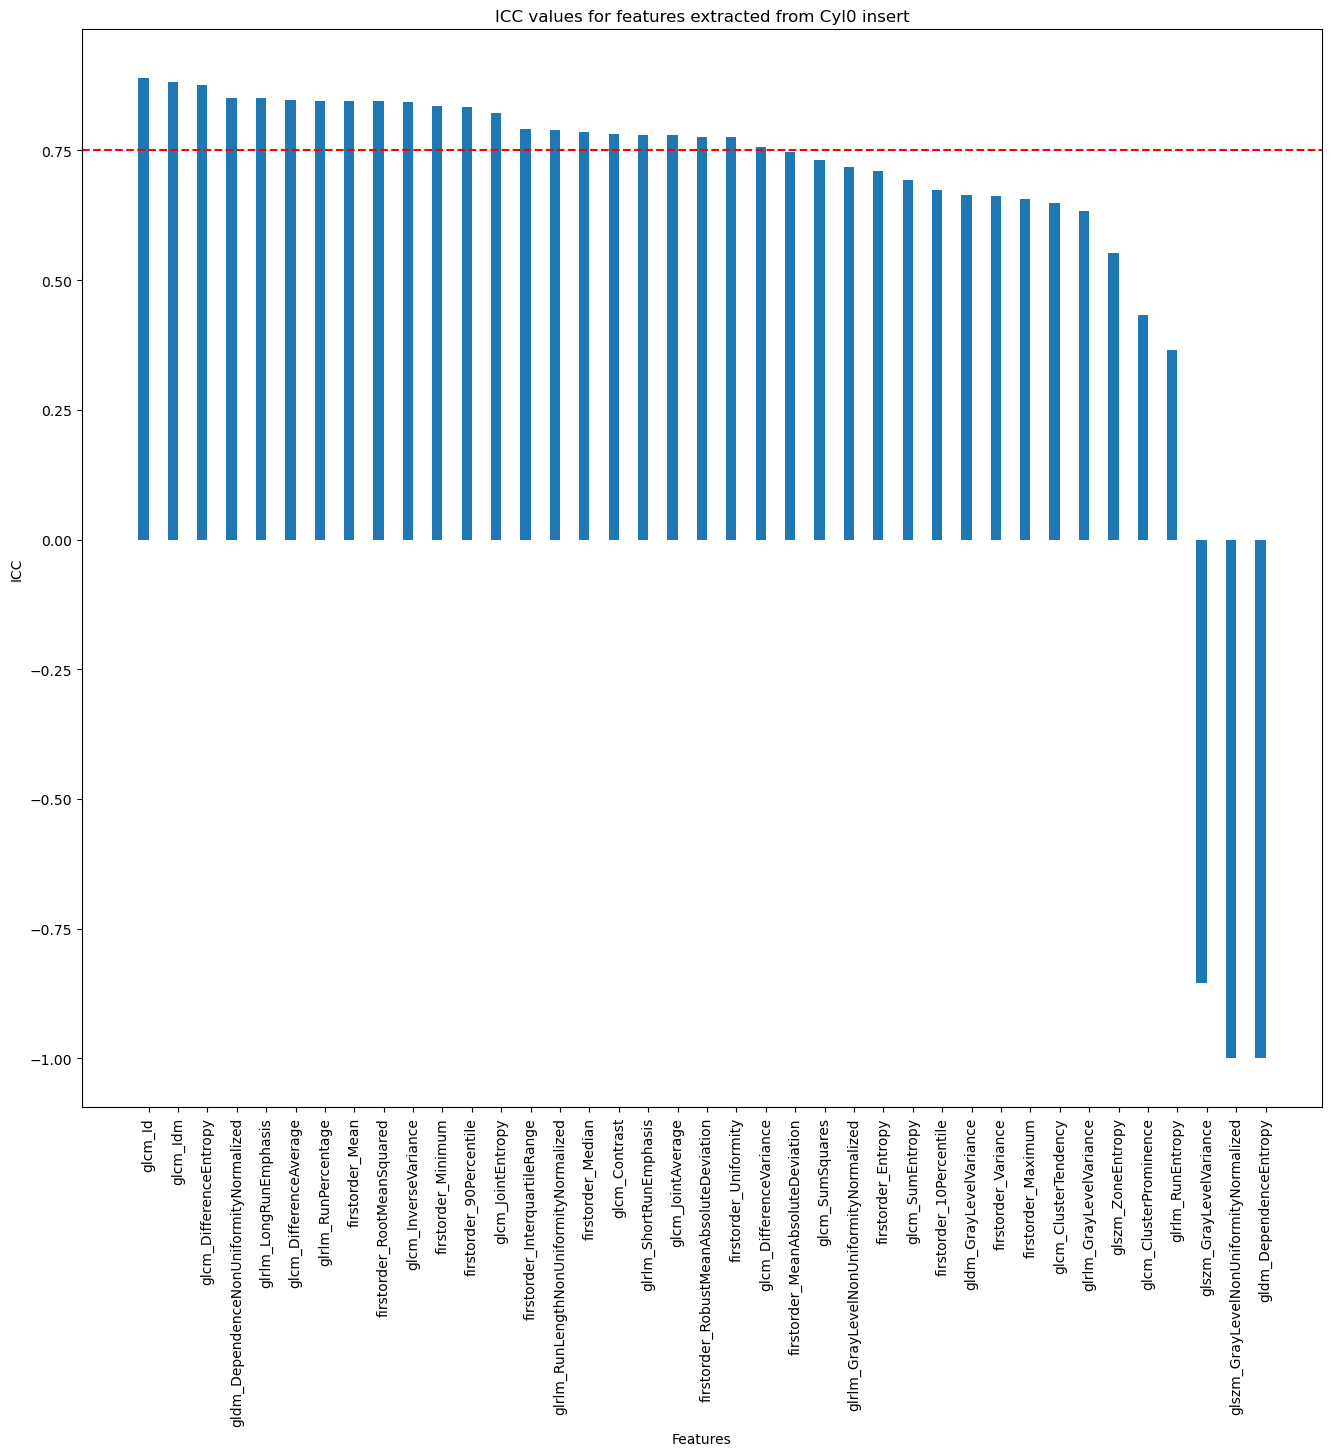

In [40]:
substring = 'original_'
new_column_names = []
for i in range(len(result_ALL['name'])):
    new_string = result_ALL['name'][i].replace(substring, "")
    new_column_names.append(new_string)

#Plot the histogram
plt.figure(figsize=(16,14))

transformed_numbers_all = [-1 if num < -1 else num for num in result_ALL['ICC']]
#transformed_numbers_dprime = [-1 if num < -1 else num for num in result_ALL['ICC_y']]

bar_width = 0.35

# Set the positions of the bars on the x-axis
bar_positions1 = np.arange(len(transformed_numbers_all))
bar_positions2 = bar_positions1 + bar_width

plt.bar(bar_positions1, transformed_numbers_all, bar_width, align='center', label='all')
#plt.bar(bar_positions2, transformed_numbers_dprime, bar_width, align='center', label = 'similar dprime')

# Set custom labels for the x-axis ticks
plt.xticks(bar_positions1 + bar_width/2, new_column_names, rotation=90)
#plt.xticks(rotation=90)

# Add labels and title

plt.xlabel('Features')
plt.ylabel('ICC')
plt.title('ICC values for features extracted from Cyl0 insert')

plt.axhline(y=0.75, color='r', linestyle='--')

# Show the plot
plt.show()

In [41]:
Excellent_value_count = len(result_ALL[result_ALL['R'] == 'Excellent'])
print(f'Excellent:', Excellent_value_count)
Good_value_count = len(result_ALL[result_ALL['R'] == 'Good'])
print(f'Good:', Good_value_count)
Moderate_value_count = len(result_ALL[result_ALL['R'] == 'Moderate'])
print(f'Moderate:', Moderate_value_count)
Poor_value_count = len(result_ALL[result_ALL['R'] == 'Poor'])
print(f'Poor:', Poor_value_count)
Inconsistent_value_count = len(result_ALL[result_ALL['R'] == 'Inconsistent'])
print(f'Inconsistent:', Inconsistent_value_count)

Excellent: 0
Good: 22
Moderate: 12
Poor: 3
Inconsistent: 2


<Figure size 640x480 with 0 Axes>

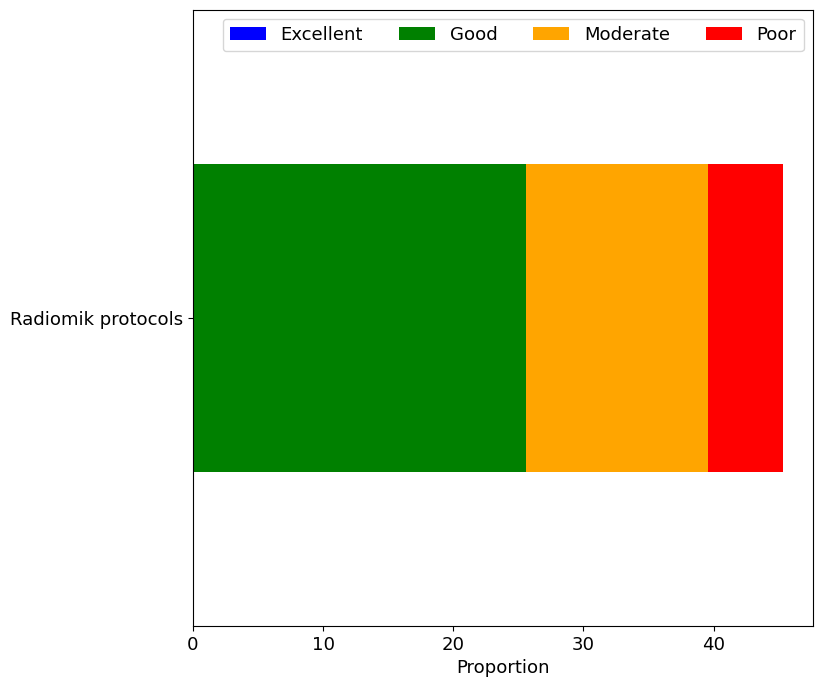

In [42]:
array = np.array([[Excellent_value_count*100/86, Good_value_count*100/86, Moderate_value_count*100/86, (Poor_value_count+Inconsistent_value_count)*100/86],  #[0*100/86, 34*100/86, 17*100/86, (11+24)*100/86]
                  ])


index_values = ['Radiomik protocols']
column_values = ['Excellent', 'Good', 'Moderate', 'Poor']
df_fig = pd.DataFrame(data = array,
                  index = index_values,
                  columns = column_values)

plt.figure()
df_fig.plot(kind="barh", figsize =(8, 8), fontsize=13, rot=0, stacked=True, color=['blue', 'green', 'orange', 'red'])
#plt.ylabel('Reconstruction Algorithm',fontsize=13)
plt.xlabel('Proportion',fontsize=13)
plt.legend(bbox_to_anchor =(1, 1),fontsize=13, ncol=4)
plt.savefig('Boxplot.png')